# 073 — Statistical models for the fragility comparison

Fits the A-series models of `admin/analysis_models.md` to the dataset nb `072` writes.

Everything here runs on `phd_project/scripts/fragility_data_models.py`, which owns the loading,
the crossed factors, the sampling covariance and the model registry. Notebook `076_refactor`
documents that data model and is the place to look for *how it works*; this notebook is for the
results.

**The three arms** (CLAUDE.md §2), all on the log scale:

| symbol | arm | varies with | record set |
|---|---|---|---|
| $a_i$ | MSA site-specific | site & structure | selected per stripe, per site, by GCIM |
| $b_j$ | MSA fixed set | design only | one fixed FEMA P695 set, shared |
| $c_j$ | IDA fixed set | design only | the same fixed set |

**The contrasts.** $y^{(0)}_i = a_i - c_{g[i]}$ (120 rows), $y^{(1)}_i = a_i - b_{g[i]}$
(120 rows), $y^{(2)}_j = b_j - c_j$ (51 rows). The identity
$y^{(0)}_i \equiv y^{(1)}_i + y^{(2)}_{g[i]}$ holds exactly at row level — but see §3.0 for why
the *fitted summaries* do not simply add.

**Models fitted here:** A0a, A1a and A2, each by DerSimonian–Laird and by REML, plus §2.4's
collapse-bracket variants. A1b and A1c — the three-level and crossed design × site fits, which
are the reportable A1 rungs — are **not** fitted yet.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from phd_project.scripts.femap695_records import femap695_record_tags
import phd_project.scripts.metaregression_analysis as mra
import phd_project.scripts.fragility_data_models as fm
from phd_project.config import config

cfg = config.load_config()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

## 1.0 Load

One call replaces what used to be three cells of hand-written setup — five estimate frames, five
replicate dicts, ten reshapes and fourteen log transforms producing about thirty module-level
names.

Note there is no `K_SAMPLES` literal: the replicate count is read from the files and reported as
`theta.k`. The previous version of this notebook hardcoded `K_SAMPLES = 10` and could no longer
run at all once the bootstrap was re-run at 5000.

`n_storeys` is left at `None`, the full 120-row study. Restricting it gives the provisional
60-row / 25-group 3-storey subset that CLAUDE.md §1 warns about, and the loader flags it.

In [3]:
IM_TAG = "AvgSA_03"
BOOTSTRAP_PTH = cfg["proc_data"]["bootstrapping"]

theta = fm.load_fragility_data(BOOTSTRAP_PTH, IM_TAG, quantity="theta")

  msa_fx   (b    ):  51 x 5000 replicates
  ida_fx   (c    ):  51 x 5000 replicates
  ida_ub   (c_ub ):  51 x 5000 replicates
  ida_avg  (c_avg):  51 x 5000 replicates
  msa_ss   (a    ): 120 x 5000 replicates
checks:
  y0 == y1 + y2[g[i]]        : ok (estimates and all replicates)
  v1 == v_a + V_bb[g,g]      : ok to MC error (implied corr mean -0.0011, max |z| 2.2 sigma)
  V_bb mean off-diag corr    : +0.4091 (min eig -5.79e-19, k/J 98.0)
  dataset var == cloud var   : ok for every loaded arm
  shape                      : n=120, J=51, sites=60, k=5000


The check report above is run at load. The sharpest line is the first: the roadmap identity
$y^{(0)} = y^{(1)} + y^{(2)}[g[i]]$ tested on the point estimates and on every replicate, which
passes only if the design indicator, the label-based group expansion and the replicate alignment
are all correct at once.

**On the log scale.** All three arms are carried as logs throughout. Taking the log regularises
the distributions — a median collapse capacity is positive and right-skewed, and its log is far
closer to normal, which is what the random-effects model assumes. A difference of logs is a log
*ratio*, so $e^{\hat m}$ reads directly as "IDA under-estimates the median capacity by this
factor", which is the form an engineer can use.

The cost is that the log of an unbiased estimator is not unbiased (Jensen), so nb `070` computes
a bias term per arm and nb `072` carries it. It is available as
`theta.hat(symbol, corrected=True)` but is **not** used below: Efron & Tibshirani (Ch. 10,
~p. 128) note that correcting inflates variance and is often not worth it, and in a *difference*
of two similarly-biased log-medians the bias largely cancels.

In [4]:
print(theta.summary())
theta.rows.head()

FragilityData(quantity='theta', im_tag='AvgSA_03')
  rows        : 120  (60 sites x storeys [3, 5])
  designs     : 51
  replicates  : 5000
  arms loaded : b, c, c_ub, c_avg, a


structure_id               tag design_group_id  n_sites_in_group  is_representative  msa_fx_theta  msa_fx_log_theta  msa_fx_theta_bc  msa_fx_log_theta_bc  msa_fx_var_theta  \
site n_storeys                                                                                                                                                                                
0    3                     0  3s_cbf_dc2_site0     group_3s_00                 8               True      0.411665         -0.887545         0.411665            -0.887545          0.000324   
     5                    25  5s_cbf_dc2_site0     group_5s_00                21               True      0.351892         -1.044431         0.351892            -1.044431          0.000228   
1    3                     1  3s_cbf_dc2_site1     group_3s_01                 6               True      0.392731         -0.934629         0.392731            -0.934629          0.000212   
     5                    25  5s_cbf_dc2_site1     group_5s_00                21              False      0.351892         -1.044431         0.351892            -1.044431          0.000228   
2    3                     1  3s_cbf_dc2_site2     group_3s_01                 6              False      0.392731         -0.934629         0.392731            -0.934629          0.000212   

                msa_fx_var_log_theta  msa_fx_log_theta_bias  msa_fx_n_obs  ida_fx_theta  ida_fx_log_theta  ida_fx_theta_bc  ida_fx_log_theta_bc  ida_fx_var_theta  ida_fx_var_log_theta  \
site n_storeys                                                                                                                                                                            
0    3                      0.001906              -0.000105          5000      0.393142         -0.933584         0.393142            -0.933584          0.000308              0.001981   
     5                      0.001827               0.000433          5000      0.340030         -1.078723         0.340030            -1.078723          0.000176              0.001524   
1    3                      0.001356               0.000818          5000      0.382000         -0.962336         0.382000            -0.962336          0.000231              0.001573   
     5                      0.001827               0.000433          5000      0.340030         -1.078723         0.340030            -1.078723          0.000176              0.001524   
2    3                      0.001356               0.000818          5000      0.382000         -0.962336         0.382000            -0.962336          0.000231              0.001573   

                ida_fx_log_theta_bias  ...  ida_ub_var_theta  ida_ub_var_log_theta  ida_ub_log_theta_bias  ida_ub_n_obs  ida_avg_theta  ida_avg_log_theta  ida_avg_theta_bc  ida_avg_log_theta_bc  \
site n_storeys                         ...                                                                                                                                                          
0    3                      -0.000270  ...          0.000356              0.001969              -0.000214          5000       0.408397          -0.895515          0.408397             -0.895515   
     5                      -0.000450  ...          0.000188              0.001409              -0.000490          5000       0.352808          -1.041832          0.352808             -1.041832   
1    3                      -0.000215  ...          0.000246              0.001440              -0.000184          5000       0.396916          -0.924031          0.396916             -0.924031   
     5                      -0.000450  ...          0.000188              0.001409              -0.000490          5000       0.352808          -1.041832          0.352808             -1.041832   
2    3                      -0.000215  ...          0.000246              0.001440              -0.000184          5000       0.396916          -0.924031          0.396916             -0

## 2.0 Statistical models

The registry holds every fit, keyed by its roadmap id, and refuses to overwrite one silently.
That matters here: the previous version of this notebook rebound `y0`, `v0_boot`, `T_sq`, `lb`,
`ub` and friends in each section, so re-running the A1 block after A2 left A2's numbers in
variables named as though they belonged to A1.

`n_boot` is set to every stored replicate, because these are the reportable numbers. That makes
this notebook take some minutes to run; `076_refactor` uses 500 for responsiveness.

In [5]:
fits = fm.ModelRegistry(theta)
N_BOOT = 500 # theta.k          # all of them - these are the reportable fits

for model_id in fm.MODEL_SPECS.keys():
    fits.fit(model_id, n_boot=N_BOOT, verbose=True)

  A0a [DL]: outer bootstrap over 500 replicates...
  A0a [REML]: outer bootstrap over 500 replicates...
  A0b [REML]: outer bootstrap over 500 replicates...
  A0c [REML]: outer bootstrap over 500 replicates...
  A0d [REML]: outer bootstrap over 500 replicates...
  A1a [DL]: outer bootstrap over 500 replicates...
  A1a [REML]: outer bootstrap over 500 replicates...
  A1b [REML]: outer bootstrap over 500 replicates...
  A1c [REML]: outer bootstrap over 500 replicates...
  A2 [DL]: outer bootstrap over 500 replicates...
  A2 [REML]: outer bootstrap over 500 replicates...
  A2_ub [DL]: outer bootstrap over 500 replicates...
  A2_ub [REML]: outer bootstrap over 500 replicates...
  A2_avg [DL]: outer bootstrap over 500 replicates...
  A2_avg [REML]: outer bootstrap over 500 replicates...


### 2.1 A0a — MSA site-specific vs IDA fixed set

$e^{\hat m_0}$ is the factor an engineer would apply to a FEMA-P695-style IDA fragility to recover the site-specific answer (on average). As we will see there is still significant error associated with just using the intercept as the correction factor.

Three standard errors are reported, and they answer different questions — `076_refactor` §4.1
works through why. In short: `SE (superpop.)` includes $\tau$ and so covers a *new* structure;
`SE (sampling)` is $\sqrt{w'Vw}$ and covers *these* 120; `SE (bootstrap)` is the measured version
of the second, and the two agreeing is a check that the covariance is being carried.

Lead with the **prediction interval**, not the confidence interval. The CI says where the mean
correction lies; the PI says where the next building lands (Borenstein Ch. 17).

In [6]:
print(fits["A0a"].summary())

A0a [REML]  MSA-SS / IDA-FX  (y0 = a - c, theta, n=120)
  summary effect   : 1.0719   (log +0.0695)
  95% CI           : 1.0203 - 1.1102     <- where the MEAN effect lies
  95% PI           : 0.8997 - 1.2772     <- where the NEXT case lands
  SE (superpop.)   : 0.02346   <- includes tau: a NEW structure
  SE (sampling)    : 0.02049   <- sqrt(w' V w), these structures
  SE (bootstrap)   : 0.02043   <- 500 refits
  tau_u            : 0.0861   (a factor of 1.090)
  Q                : 456.52 on 119 df, p = 5.11e-41   (excess over null +337.52)
    -> p is nominal: Q uses the diagonal v, but rows here share sampling error (a common b_j / c_j), which inflates Q
  I_sq             : 74.5%   [T^2 / (s^2 + T^2), REML T^2]   (secondary - see Borenstein Ch. 16: I_sq is a PROPORTION of variance that is real, and with small sampling variances it tends to 1 almost regardless)
  The headline: site-specific MSA against fixed-set IDA, intercept only. exp(m0) is the correction factor an engineer would a

In [7]:
print(fits["A0a", "DL"].summary())

A0a [DL]  MSA-SS / IDA-FX  (y0 = a - c, theta, n=120)
  summary effect   : 1.0398   (log +0.0390)
  95% CI           : 0.9846 - 1.0932     <- where the MEAN effect lies
  95% PI           : 0.8726 - 1.2390     <- where the NEXT case lands
  SE (superpop.)   : 0.00906   <- includes tau: a NEW structure
  SE (sampling)    : 0.02577   <- sqrt(w' V w), these structures
  SE (bootstrap)   : 0.02514   <- 500 refits
    -> fitted with a DIAGONAL sampling covariance: the model-based SE omits the off-diagonal entirely, and the weights ignore that rows in a design share an arm.
  tau_u            : 0.0849   (a factor of 1.089)
  Q                : 456.52 on 119 df, p = 5.11e-41   (excess over null +337.52)
  I_sq             : 73.9%   [(Q - df) / Q]   (secondary - see Borenstein Ch. 16: I_sq is a PROPORTION of variance that is real, and with small sampling variances it tends to 1 almost regardless)
  The headline: site-specific MSA against fixed-set IDA, intercept only. exp(m0) is the correction

The DL fit is kept as the Borenstein Ch. 12/14 hand-calculation reference and as the regression
test for the REML implementation — not as a reportable result. Its model-based SE is roughly
three times too small, because DL takes a variance *vector* and so cannot represent the fact that
every row in a design group subtracts the same $c_j$. It also loses real precision: compare the
two `SE (sampling)` values, which are the like-for-like comparison on identical replicates.

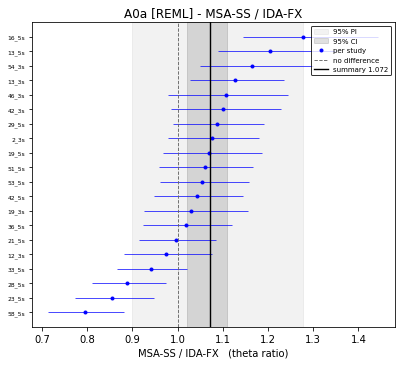

In [8]:
ax = fits.forest("A0a", max_rows=20)

### 2.2 A1 — MSA site-specific vs MSA fixed set

The pure **record-set** effect: the analysis procedure is held constant and only the record selection changes. This is the contrast the study exists to measure.

#### 2.2.1 A1a - Diagonal Matrix
A1a is the one rung where a diagonal `V_known` is exactly right on the diagonal, since the two
arms use disjoint record sets and so $v_1[i] = v_a[i] + V_{bb}[g[i],g[i]]$ exactly. That is a
statement about the *diagonal* only — rows sharing a design still share $b_j$, which is what A1b
and A1c exist to handle and why A1a's $\tau^2$ is a baseline rather than a reportable number.

In [9]:
print(fits["A1a"].summary())

A1a [REML]  MSA-SS / MSA-FX  (y1 = a - b, theta, n=120)
  summary effect   : 0.9976   (log -0.0024)
  95% CI           : 0.9409 - 1.0533     <- where the MEAN effect lies
  95% PI           : 0.8359 - 1.1905     <- where the NEXT case lands
  SE (superpop.)   : 0.00916   <- includes tau: a NEW structure
  SE (sampling)    : 0.02766   <- sqrt(w' V w), these structures
  SE (bootstrap)   : 0.02728   <- 500 refits
    -> fitted with a DIAGONAL sampling covariance: the model-based SE omits the off-diagonal entirely, and the weights ignore that rows in a design share an arm.
  tau_u            : 0.0850   (a factor of 1.089)
  Q                : 426.25 on 119 df, p = 3.54e-36   (excess over null +307.25)
  I_sq             : 72.7%   [T^2 / (s^2 + T^2), REML T^2]   (secondary - see Borenstein Ch. 16: I_sq is a PROPORTION of variance that is real, and with small sampling variances it tends to 1 almost regardless)
  Site-specific MSA against fixed-set MSA: the pure record-set effect, with the a

In [10]:
fits["A1a"].het

{'Q': np.float64(426.2472291767016),
 'df': 119,
 'Q_df': np.float64(307.2472291767016),
 'p': 3.5413797211771554e-36,
 's_sq': 0.0027110146204264926,
 'T_sq': 0.007224890708619811,
 'T': np.float64(0.08499935710709705),
 'I_sq': 72.71497130209967}

#### 2.2.2 A1b - Building Groups

This model shows the effect of not considering the site term when using the full covariance model.

In [11]:
print(fits["A1b"].summary())

A1b [REML]  MSA-SS / MSA-FX  (y1 = a - b, theta, n=120)
  summary effect   : 1.0364   (log +0.0358)
  95% CI           : 0.9880 - 1.0693     <- where the MEAN effect lies
  95% PI           : 0.8686 - 1.2367     <- where the NEXT case lands
  SE (superpop.)   : 0.02328   <- includes tau: a NEW structure
  SE (sampling)    : 0.01917   <- sqrt(w' V w), these structures
  SE (bootstrap)   : 0.01973   <- 500 refits
  tau_d            : 0.0000   (a factor of 1.000)
  tau_u            : 0.0870   (a factor of 1.091)
  Q                : 426.25 on 119 df, p = 3.54e-36   (excess over null +307.25)
    -> p is nominal: Q uses the diagonal v, but rows here share sampling error (a common b_j / c_j), which inflates Q
  I_sq             : 73.6%   [T^2 / (s^2 + T^2), REML T^2]   (secondary - see Borenstein Ch. 16: I_sq is a PROPORTION of variance that is real, and with small sampling variances it tends to 1 almost regardless)
  Site-specific MSA against fixed-set MSA: the pure record-set effect, with

#### 2.2.3 A1c - Crossed Structure: Buildings and Sites

In this model the between-study variance is split into building group effects, site effects and random effects. This is the first step in understanding what the between site variance is due to.

Rows in the same building group can be alike for two reasons:
1. a real design effect (i.e. they share a building which has a noticeable effect on the observed value of y1)
2. the value of b_j (MSA-FX for building j) has a large/noisy sampling variance and shared by all the rows with the same building design.

We can run two analyses. One with the diagonal V matrix and one with the full variance matrix. The V matrix tells the REML algorithm how much sampling variance (i.e. from the bootstrap fits) we have. If it is diagonal then there is no covariance between the sites/structure combinations being modelled. This means that REML does not know that multiple rows (site/structure combinations) share the same value of b_j and its associated sampling variance. 

If we use the full V-matrix (V_aa + ZV_bbZ') then we model the covariance in the sampling variance and the REML algorithm knows that some sites share designs and therefore a source of sampling variance. Doing an analysis with the full V-Matrix will then tell us if there is any actually a difference between the sites. Vaa contains covariance between rows due to both shared structures and shared sites. V_bb adds covariance due to shared structures.

The following A1c analysis uses the full V-Matrix

In [12]:
print(fits["A1c"].summary())

A1c [REML]  MSA-SS / MSA-FX  (y1 = a - b, theta, n=120)
  summary effect   : 1.0099   (log +0.0099)
  95% CI           : 0.9728 - 1.0453     <- where the MEAN effect lies
  95% PI           : 0.8443 - 1.2079     <- where the NEXT case lands
  SE (superpop.)   : 0.02172   <- includes tau: a NEW structure
  SE (sampling)    : 0.01659   <- sqrt(w' V w), these structures
  SE (bootstrap)   : 0.01835   <- 500 refits
  tau_d            : 0.0000   (a factor of 1.000)
  tau_s            : 0.0856   (a factor of 1.089)
  tau_u            : 0.0228   (a factor of 1.023)
  Q                : 426.25 on 119 df, p = 3.54e-36   (excess over null +307.25)
    -> p is nominal: Q uses the diagonal v, but rows here share sampling error (a common b_j / c_j), which inflates Q
  I_sq             : 74.3%   [T^2 / (s^2 + T^2), REML T^2]   (secondary - see Borenstein Ch. 16: I_sq is a PROPORTION of variance that is real, and with small sampling variances it tends to 1 almost regardless)
  Site-specific MSA again

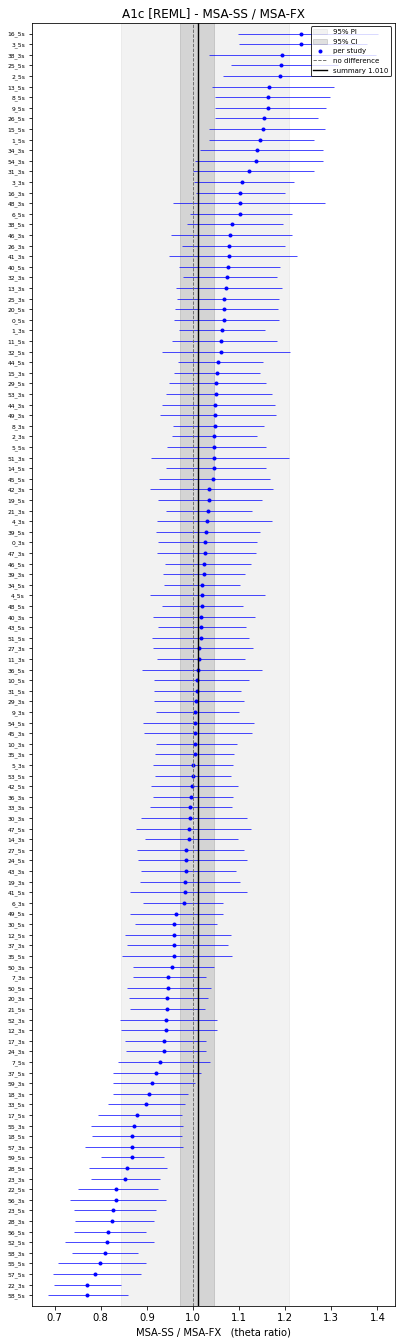

In [13]:
ax = fits.forest("A1c")

The results of this analysis are:
1. $m_1$ is 1.0099 with a prediction interval of 0.844 - 1.208
1. $\tau_d$ is zero
2. $\tau_s$ is much larger (0.086) --> ~93% of the variance
3. $\tau_u$ is smaller (0.023) --> ~7% of the variance

The average effect across all sites and structures is 1.0099 (basically no difference between MSA-SS and MSA-FX),  indicating that a fixed record set (of a type similar to the FEMA-P695 record set) does not appear to be biased on average for the 60 representative European sites used in this study, however the 95% prediction interval is relatively wide 0.844 -> 1.208  (-16% to +21%). This indicates that the error at for an individual site (site/structure combination) may be quite large.

A variance decomposition shows that the variation due to differences in building designs is negligible (which is somewhat to be expected because the buildings are all relatively similar - 3s and 5s steel CBF structures.) The variation associated with between-site diffrences is ~93% of the total variance. The remaining 7% is the random effect

A regression analysis on this data would be useful for identifying parameters that can reduce the between-site variance. Such a regression model could also be used to provide a "correction factor" when using a fixed record set. 

**Be Careful** The large share in site variance is possibly due to the wide variation in site characteristics compared to the relatively narrow group of structures (3s and 5s steel CBFs). Variance share is related to the sampled range so the large range so have the more variance share is associated with it. That is possible why the sites look so dominant here. It is true in this case but we must be careful not to generalise it too far! --> see (Gelman & Hill Ch. 21, ~p. 459–463, approx.)

In [14]:
band = fits.table(["A1a", "A1b", "A1c"])
band.loc[(slice(None), "REML"),
         ["contrast", "ratio", "se_boot", "ci_lo", "ci_hi"]].round(4)

,,contrast,ratio,se_boot,ci_lo,ci_hi
model,estimator,,,,,
A1a,REML,y1,0.9976,0.0273,0.9409,1.0533
A1b,REML,y1,1.0364,0.0197,0.9880,1.0693
A1c,REML,y1,1.0099,0.0184,0.9728,1.0453


The mean ratio shifts between models depending on the variance components considered and the if the full sampling matrix with covariance is considered or not. A1b is evidence that not including the site term in the model skews the results as the weights in the REML algorithm treat the within-site similarity as if it were sampling noise. --> A0 needs the same decomposition as well before conclusions can be drawn regarding the differences between MSA-SS and IDA-FX.

### 2.3 A2 — MSA fixed set vs IDA fixed set

Both arms use the same records, so the record effect cancels and what is left is the
**procedure** effect: stripe-count binomial MLE against lognormal-of-capacities.

Fitted at **51 rows**, because one row is one design — the fixed-set stripe IMLs come from the span of the fragility curve rather than from site hazard, so these arms depend on the design only (analysis_models.md §1(b)).

In [15]:
print(fits["A2"].summary())

A2 [REML]  MSA-FX / IDA-FX  (y2 = b - c, theta, n=51)
  summary effect   : 1.0450   (log +0.0441)
  95% CI           : 1.0421 - 1.0498     <- where the MEAN effect lies
  95% PI           : 1.0244 - 1.0660     <- where the NEXT case lands
  SE (superpop.)   : 0.00245   <- includes tau: a NEW structure
  SE (sampling)    : 0.00156   <- sqrt(w' V w), these structures
  SE (bootstrap)   : 0.00178   <- 500 refits
  tau_u            : 0.0097   (a factor of 1.010)
  Q                : 37.94 on 50 df, p = 0.895   (excess over null -12.06)
    -> p is nominal: Q uses the diagonal v, but rows here share sampling error (a common b_j / c_j), which inflates Q
  I_sq             : 28.0%   [T^2 / (s^2 + T^2), REML T^2]   (secondary - see Borenstein Ch. 16: I_sq is a PROPORTION of variance that is real, and with small sampling variances it tends to 1 almost regardless)
  Fixed-set MSA against fixed-set IDA, at 51 rows because one row IS one design -- the fixed-set stripe IMLs come from the fragility 

$\tau$ for the DL fit goes to almost zero and the random-effects model approximates the fixed-effects one (`Q` minus the dfs is < 0 (-12.06)). That is to be expected: the structure itself, at least within this group of steel CBFs, has no effect on the ratio of median collapse capacity between MSA-FX and IDA-FX. When $\tau \approx 0$ the prediction interval collapses onto the confidence interval of the mean, since there is no between-design variation left for a new design to be drawn from. The REML results show that tau_u is not zero but the variance is very small $\tau \approx 0.0097$.

The mean (fixed) effect is about **1.045** — IDA *underestimates* the median capacity by roughly 4.5% relative to the MSA on the same records. The cause of this systematic under-estimation comes from the choice of the definition of the collapse IML in the HTF-IDA algorithm of Vamvatsikos & Cornell, not a property of the records. This is explore furth in §2.4.

### 2.4 The collapse bracket — IDA-FX read three ways

An IDA resolves each record's capacity only to a **bracket**: between the highest intensity that ran and the lowest that collapsed. Vamvatsikos and Cornell use the highest converging run as the collapse capacity, although they note that the average or the lowest non-converging run could also be used. Up until this point that is what I have been using as well. This section shows that this is the source of the ~4.5% bias seen in §2.3.

The A2 comparison (y2 = b - c) was made for 3 different definitions of c:
1. The *highest converging run* (standard IDA as proposed by Vamvatsikos and Cornell) --> A lower bound
2. The *lowest nonconverging run* --> an upper bound
3. The *geometric average* of 1. and 2. --> a middle value

In [16]:

band = fits.table(["A2", "A2_avg", "A2_ub"])
band.loc[(slice(None), "REML"),
         ["contrast", "n", "ratio", "se_boot", "ci_lo", "ci_hi"]].round(4)

,,contrast,n,ratio,se_boot,ci_lo,ci_hi
model,estimator,,,,,,
A2,REML,y2,51,1.0450,0.0018,1.0421,1.0498
A2_ub,REML,y2_ub,51,0.9680,0.0023,0.9649,0.9739
A2_avg,REML,y2_avg,51,1.0057,0.0019,1.0027,1.0109


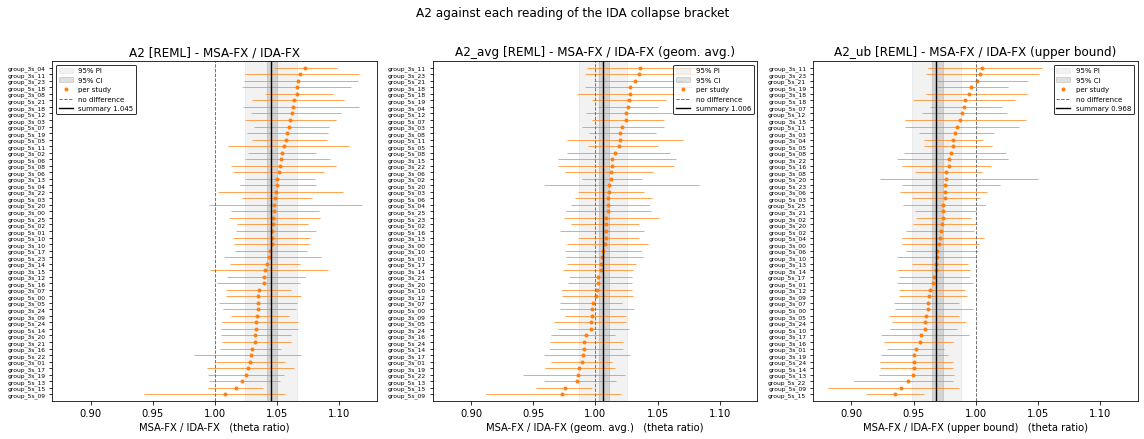

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharex=True)
estimator = "REML"
for ax, model_id in zip(axes, ("A2", "A2_avg", "A2_ub")):
    fits.forest(model_id, estimator=estimator, ax=ax)
fig.suptitle("A2 against each reading of the IDA collapse bracket", y=1.01)
fig.tight_layout()
plt.show()

In [18]:
# Mean width of the IDA collapse bracket, ln(ub / lb), over every record of every design
# group. This is the number the discussion below compares with ln(M*_L) - ln(M*_U): under
# the uniform-in-log assumption the lower- and upper-bound effects should sit exactly one
# mean bracket width apart.

record_tags = femap695_record_tags(cfg["raw_data"]["femap695_records"])
iml_stem = Path(cfg["proc_data"]["wp1_groups_femap695_collapse_imls"])

# The loader returns {n_storeys: table}; stack the storey tables into one 51 x 22 frame.
# The suffix picks the bracket end: "" is the lower bound, "_ub" the upper bound.
lb_imls, ub_imls = (
    pd.concat(mra.load_group_collapse_imls(
        iml_stem.with_name(f"{iml_stem.stem}_{IM_TAG}{suffix}.csv"), [3, 5], record_tags
    ).values())
    for suffix in ("", "_ub"))

# Log bracket width per (group, record). Every group has the same 22 records, so the
# grand mean equals nb 074's mean of per-group means.
log_bracket = np.log(ub_imls / lb_imls)
mean_bracket = log_bracket.to_numpy().mean()

print(f"Mean of the log of the ida collapse bracket: {mean_bracket:.4f}")
print(f"Mean ida collapse bracket in real units: {np.exp(mean_bracket):.4f}")
print(f"Estimated prediction error in real units: {0.5 * (1 - np.exp(mean_bracket)):.4f}")

Mean of the log of the ida collapse bracket: 0.0732
Mean ida collapse bracket in real units: 1.0759
Estimated prediction error in real units: -0.0379


From the forestplots and the mean effect size we can see that when we take the highest non collapsed iml in the IDA as our collapse capacity we are biasing the collapse capacity downwards compared to the MSA result. If we take the lowest collapsed iml then the collapse capacity is biased upwards compared to the MSA result. Finally, if the geometric average of the upper and lower bound iml is used then the results are unbiased with respect to the MSA results.

The bias of ~4.5% can be explained as follows:

The error between the "true" collapse value, $T_i$, and the lower bound value, $L_i$, for record $i$ is $$\varepsilon_i = \ln{\frac{T_i}{L_i}} \in \left(0, \ln\frac{U_i}{L_i}\right)$$ where $U_i$ is the upper bound value on the collapse capacity for the record $i$. From the definition of the IDA algorithm that has been implemented we know that the ratio $r=\frac{U_i}{L_i}\leq1.1$, i.e. the maximum difference between the upper and lower collapse bound is 10%. If we assume that $T_i$ is uniformly distributed on $\left(L_i, U_i\right)$ then $\varepsilon_i$ is uniformly distributed on $\left(0, \ln\frac{U_i}{L_i}\right) = (0, \ln{1.1})$. Calculating the expectation of $X\sim\mathcal{U}(a,b)$ is $$\mathbb{E}[X] = \frac{(a + b)}{2}$$ so the expectation of $\varepsilon$ is $$\mathbb{E}[\varepsilon_i] = \frac{(0 + \ln{1.1})}{2} = 0.04766$$ taking the exponential converts this into real units and we get 1.0488 or a 4.9% underestimation by IDA. Following this logic is it clear that if we substitute $U_i$ for $L_i$ then we would expected the same error just in the other direction, and substituting the geometric average for $L_i$ we would get no expected error.

The cell above calculates the mean collapse bracket width across all structures and records: 7.59% over all 51 groups. This is less than the 10% assumed above because the IDA algorithm used makes the trace step the minimum of 1/3 the distance between the last noncollapse iml and the lowest collapse iml or 10% of the last noncollapse iml. This means that in some cases the band width is less than 10% which drags down the mean. Halving this mean collapse bracket value gives and expected error (assuming a uniform distribution) of approximately 3.8%, which is smaller than the ~4.5% that we see from the meta analysis. There is ~0.6% error remaining.

Based on the uniform assumption we would expect the average of the log of the mean effects of the upper and lower collapse imls to be zero. $$0.5(\ln{M^*_L}+\ln{M^*_U}) = 0.5(\ln{1.045} + \ln{0.968}) = 0.00575$$ This is not zero, which indicates some level of bias. The bias is approximately $3.2\times SE$ ($SE = 0.0018$ from the bootstrap). The residual is therefore significantly different from zero at 95% confidence, however it is small and of little practical significance. This calculation is verified by looking at the A2_avg directly. This 0.00575 is the approximate 0.6% error above. It could be due to several things:
1. The true capacity sits above the log midpoint (i.e. it is not uniformly distributed)
2. The MSA estimator is slightly biased due to the finite stripe counts. `nb 070` shows that this is small and would acocunt for some but not all. 

The conclusions from this investigation are:
1. The the HTF algorithm as implemented by Vamvatsikos and Cornell (taking the highest noncollapsing IML) results in an ~4.5% underestimation in the median collapse capacity compared to MSA results with the same record set. Vamvatsikos says that the average or the upper bound would also be ok choices.
2. If this difference is corrected for i.e. the geometric average of the upper and lower bound is used to predict the collapse capacity then there is no meaningful difference in the values of median fragility obtained from IDA and MSA. (based on the structures that we have assessed here)

What does this mean for the rest of my models?
1. We can redfine the collapse point of the IDA-FX and then use the redefined collapse capacities to better estimate the difference between MSA-SS and IDA-FX 

### 2.5 A0b — MSA site-specific vs IDA fixed set : Avg Collapse IML

A0b [REML]  MSA-SS / IDA-FX (geom. avg.)  (y0_avg = a - c_avg, theta, n=120)
  summary effect   : 1.0332   (log +0.0326)
  95% CI           : 0.9834 - 1.0697     <- where the MEAN effect lies
  95% PI           : 0.8671 - 1.2311     <- where the NEXT case lands
  SE (superpop.)   : 0.02317   <- includes tau: a NEW structure
  SE (sampling)    : 0.02026   <- sqrt(w' V w), these structures
  SE (bootstrap)   : 0.02013   <- 500 refits
  tau_u            : 0.0862   (a factor of 1.090)
  Q                : 463.79 on 119 df, p = 3.38e-42   (excess over null +344.79)
    -> p is nominal: Q uses the diagonal v, but rows here share sampling error (a common b_j / c_j), which inflates Q
  I_sq             : 74.8%   [T^2 / (s^2 + T^2), REML T^2]   (secondary - see Borenstein Ch. 16: I_sq is a PROPORTION of variance that is real, and with small sampling variances it tends to 1 almost regardless)
  A0a against the GEOMETRIC MEAN of the IDA collapse bracket. See A0a.


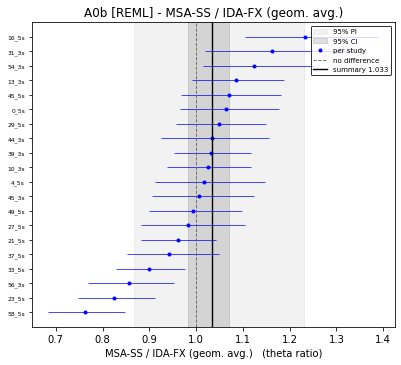

In [19]:
print(fits["A0b"].summary())
ax = fits.forest("A0b", max_rows=20)

### 2.6 A0c — MSA site-specific vs IDA fixed set : Avg Collapse IML and Decomposed

A0c [REML]  MSA-SS / IDA-FX (geom. avg.)  (y0_avg = a - c_avg, theta, n=120)
  summary effect   : 1.0135   (log +0.0134)
  95% CI           : 0.9738 - 1.0534     <- where the MEAN effect lies
  95% PI           : 0.8470 - 1.2127     <- where the NEXT case lands
  SE (superpop.)   : 0.02292   <- includes tau: a NEW structure
  SE (sampling)    : 0.01876   <- sqrt(w' V w), these structures
  SE (bootstrap)   : 0.01994   <- 500 refits
  tau_d            : 0.0000   (a factor of 1.000)
  tau_s            : 0.0860   (a factor of 1.090)
  tau_u            : 0.0206   (a factor of 1.021)
  Q                : 463.79 on 119 df, p = 3.38e-42   (excess over null +344.79)
    -> p is nominal: Q uses the diagonal v, but rows here share sampling error (a common b_j / c_j), which inflates Q
  I_sq             : 75.8%   [T^2 / (s^2 + T^2), REML T^2]   (secondary - see Borenstein Ch. 16: I_sq is a PROPORTION of variance that is real, and with small sampling variances it tends to 1 almost regardless)
  A0

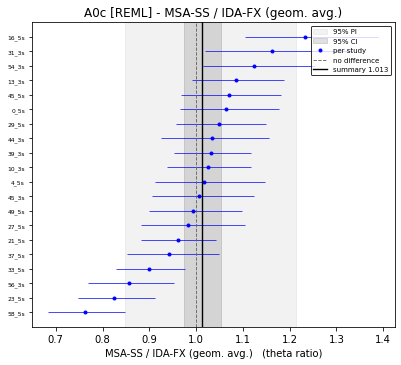

In [20]:
print(fits["A0c"].summary())
ax = fits.forest("A0c", max_rows=20)

### 2.7 A0c — MSA site-specific vs IDA fixed set : Lower Collapse IML and Decomposed

A0d [REML]  MSA-SS / IDA-FX  (y0 = a - c, theta, n=120)
  summary effect   : 1.0518   (log +0.0505)
  95% CI           : 1.0096 - 1.0937     <- where the MEAN effect lies
  95% PI           : 0.8788 - 1.2587     <- where the NEXT case lands
  SE (superpop.)   : 0.02301   <- includes tau: a NEW structure
  SE (sampling)    : 0.01873   <- sqrt(w' V w), these structures
  SE (bootstrap)   : 0.02012   <- 500 refits
  tau_d            : 0.0000   (a factor of 1.000)
  tau_s            : 0.0860   (a factor of 1.090)
  tau_u            : 0.0207   (a factor of 1.021)
  Q                : 456.52 on 119 df, p = 5.11e-41   (excess over null +337.52)
    -> p is nominal: Q uses the diagonal v, but rows here share sampling error (a common b_j / c_j), which inflates Q
  I_sq             : 75.5%   [T^2 / (s^2 + T^2), REML T^2]   (secondary - see Borenstein Ch. 16: I_sq is a PROPORTION of variance that is real, and with small sampling variances it tends to 1 almost regardless)
  A0a with the bewteen-st

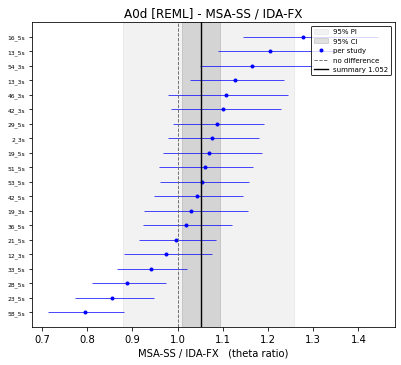

In [22]:
print(fits["A0d"].summary())
ax = fits.forest("A0d", max_rows=20)

## 3.0 Comparison across models

One call over every fit. Everything is in ratio units: `ratio` is the summary effect as a factor,
`tau_u` the case-to-case SD on the log scale, `ci_*` and `pi_*` the confidence and prediction
intervals.

In [27]:
cols = ["contrast", "n", "ratio", "se_model", "se_sampling", "se_boot",
        "tau_u", "ci_lo", "ci_hi", "pi_lo", "pi_hi"]
fits.table()[cols].round(4)

contrast    n   ratio  se_model  se_sampling  se_boot   tau_u   ci_lo   ci_hi   pi_lo   pi_hi
model  estimator                                                                                              
A0a    DL              y0  120  1.0398    0.0091       0.0258   0.0251  0.0849  0.9846  1.0932  0.8726  1.2390
       REML            y0  120  1.0719    0.0235       0.0205   0.0204  0.0861  1.0203  1.1102  0.8997  1.2772
A0b    REML        y0_avg  120  1.0332    0.0232       0.0203   0.0201  0.0862  0.9834  1.0697  0.8671  1.2311
A0c    REML        y0_avg  120  1.0135    0.0229       0.0188   0.0199  0.0206  0.9738  1.0534  0.8470  1.2127
A1a    DL              y1  120  0.9975    0.0091       0.0277   0.0273  0.0837  0.9409  1.0533  0.8380  1.1875
       REML            y1  120  0.9976    0.0092       0.0277   0.0273  0.0850  0.9409  1.0533  0.8359  1.1905
A1b    REML            y1  120  1.0364    0.0233       0.0192   0.0197  0.0870  0.9880  1.0693  0.8686  1.2367
A1c    REML            y1  120  1.0099    0.0217       0.0166   0.0184  0.0228  0.9728  1.0453  0.8443  1.2079
A2     DL              y2   51  1.0436    0.0022       0.0034   0.0034  0.0000  1.0384  1.0521  1.0364  1.0508
       REML            y2   51  1.0450    0.0024       0.0016   0.0018  0.0097  1.0421  1.0498  1.0244  1.0660
A2_ub  DL           y2_ub   51  0.9693    0.0022       0.0038   0.0039  0.0000  0.9637  0.9775  0.9617  0.9769
       REML         y2_ub   51  0.9680    0.0028       0.0019   0.0023  0.0098  0.9649  0.9739  0.9486  0.9878
A2_avg DL          y2_avg   51  1.0057    0.0022       0.0035   0.0036  0.0000  1.0006  1.0145  0.9985  1.0130
       REML        y2_avg   51  1.0057    0.0025       0.0017   0.0019  0.0094  1.0027  1.0109  0.9865  1.0253

## 4.0 What is not here yet

Tracked against `admin/analysis_models.md`:

* **A3 / A0b** — meta-regression on site and structure covariates. These need columns that do not
  exist yet anywhere in the pipeline; they belong in nb `072`'s dataset, and
  `ModelSpec.covariates` will pick them up from there.
* **A9 / A11** — the joint models, and the only honest route to comparing the decomposition
  against the headline (§3.0).
* **A12–A16** — the same ladder on the dispersion $\beta$, then the correlated $(\theta, \beta)$
  fits. The first is free — `fm.load_fragility_data(..., quantity="beta")` into a second
  registry, demonstrated at the end of `076_refactor`. The bivariate fits are not: `mra.fit_reml`
  estimates one non-negative scalar per component and cannot represent a free, possibly negative
  correlation, so A15/A16 need a new estimator or the PyMC route.

**One caveat carried forward.** `mra.compute_heterogeneity_stats` returns `Q_df = Q - (n-1)`,
which is the *excess* of Q over its null expectation rather than the degrees of freedom. The
summaries above report both under their own names; `mra` itself is unchanged.